# Visium FFPE: Tangram deconvolution with the CITE-seq reference
*Amrute et al., Science (2026) | [doi:10.1126/science.adx1736](https://doi.org/10.1126/science.adx1736)*

**Purpose.** Loads each coronary Visium FFPE section, computes QC metrics, normalizes and clusters
spots, and maps the annotated CITE-seq atlas onto every section with
[Tangram](https://github.com/broadinstitute/Tangram) to estimate per-spot cell-type composition.

**Inputs.** Space Ranger outputs (`../data/Visium_*`); CITE-seq reference `annotated_raw.h5ad` and
`meta_raw.csv` (from `human_citeseq/03_global_wnn_annotation.R`).

**Outputs.** Per-section `*.tangram.h5ad`, `*.projected.gene.h5ad` and Tangram plots in `outdir`.
`02_visium_ffpe_niches.R` reads per-spot cell-type proportions from
`../tangram/output/Visium_<sample>/Visium_<sample>.csv` (exported from `obsm["tangram_ct_pred"]`).

**Note.** Plot outputs of the per-section QC cell were cleared to keep the notebook viewable on GitHub.

In [1]:
import os,sys
import pandas as pd
import numpy as np
import scanpy as sc
import glob
import scanpy as sc
import scanpy.external as sce
import datetime
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import tangram as tg
import matplotlib as mpl
import skimage
from anndata import AnnData
import pathlib
import tangram as tg
import math

In [2]:
# EDIT: Space Ranger output folders, one per section (GEO GSE314851)
vsm_dir = "../data/Visium_*"
vsm_file = "filtered_feature_bc_matrix.h5"
rpt_file = "metrics_summary.csv"

samples = glob.glob(vsm_dir)
reports = glob.glob(vsm_dir + "/" + rpt_file)
samples.sort()
reports.sort()

outdir = "./output"

In [3]:
key = "Visium_"
adata_set = []
qc1_set = []
qc2_set = []
sample_set = []
for i in range(len(samples)):
    adata=sc.read_visium(samples[i], count_file=vsm_file)
    adata.var_names_make_unique()
    sid = [key+samples[i].split(key)[1].split("/")[0]]*adata.shape[0]
    adata.obs["sample_id"] = [key+samples[i].split(key)[1].split("/")[0]]*adata.shape[0]
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
    adata_set.append(adata)
    qc_report = pd.read_csv(reports[i], sep=",")
    qc1_set.append( qc_report[["Number of Spots Under Tissue", "Valid UMIs", "Genes Detected" ]].values.tolist()[0] )
    qc2_set.append( adata.obs[["sample_id", "pct_counts_mt", "total_counts", "n_genes_by_counts", "log1p_total_counts","log1p_n_genes_by_counts"]].values.tolist())
    sample_set.append(sid[0])

qc1_pd = pd.DataFrame(qc1_set, index=sample_set, columns = ["Number of Spots Under Tissue", "Valid UMIs", "Genes Detected" ])
qc2_pd = pd.DataFrame( [ sub2 for sub1 in qc2_set for sub2 in sub1 ], columns = ["sample", "pct_counts_mt", "total_counts", "n_genes_by_counts", "log1p_total_counts","log1p_n_genes_by_counts"])
qc1_pd["index"] = qc1_pd.index.tolist()
qc2_pd["index"] = qc2_pd.index.tolist()

In [6]:
col1 = ["Number of Spots Under Tissue", "Valid UMIs", "Genes Detected"]
fig, axs = plt.subplots(1, 3, figsize=(20, 4))
for n in range(len(col1)) :
    ax1=sns.barplot(data=qc1_pd, x='index', y=col1[n], dodge=True, ax=axs[n]);
    ax1.set_xticklabels(ax1.get_xticklabels(),rotation = 90)
    #plt.savefig(os.path.join(outdir, "QC1.bar.across.samples.pdf"), bbox_inches='tight')

plt.close()

In [7]:
col2 = ["log1p_total_counts","log1p_n_genes_by_counts"]
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
for n in range(len(col2)) :
    ax1 =sns.boxplot(x="sample", y=col2[n], data=qc2_pd, saturation=0.5, ax=axs[n])
    locs, labels = plt.xticks()
    ax1.set_xticklabels(ax1.get_xticklabels(),rotation = 90)
    #plt.savefig(os.path.join(outdir, "QC2.box.log10.across.samples.pdf"), bbox_inches='tight')

plt.close()

In [8]:
col3 = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for n in range(len(col3)) :
    ax1= sns.boxplot(x="sample", y=col3[n], data=qc2_pd, saturation=0.5, ax=axs[n])
    ax1.set_xticklabels(ax1.get_xticklabels(),rotation = 90)
    #plt.savefig(os.path.join(outdir, "QC2.box.across.samples.pdf"), bbox_inches='tight')

plt.close()

In [9]:
## preprocess
## ------------------------- ##
for n in range(len(sample_set)):
    # Normalize, get HVG
    sc.pp.normalize_total(adata_set[n], inplace=True)
    sc.pp.log1p(adata_set[n])
    sc.pp.highly_variable_genes(adata_set[n], flavor="seurat", n_top_genes=3000)
    ## PCA, UMAP 
    sc.pp.pca(adata_set[n])
    sc.pp.neighbors(adata_set[n])
    sc.tl.umap(adata_set[n])
    sc.tl.leiden(adata_set[n], resolution=1.5, key_added="clusters")
    ## Visualize
    plt.rcParams["figure.figsize"] = (4, 4)
    sc.pl.umap(adata_set[n], color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)
    #plt.savefig(os.path.join(outdir, sample_set[n]+"_qc_after_filterout.pdf"))
    plt.close()
    ## Visualization in spatial coordinates
    plt.rcParams["figure.figsize"] = (8, 8)
    sc.pl.spatial(adata_set[n], img_key="hires", color=["total_counts", "n_genes_by_counts"])
    #plt.savefig(os.path.join(outdir, sample_set[n]+".sp.pdf"))
    plt.close()
    sc.pl.spatial(adata_set[n], img_key="hires", color="clusters", size=1.5)
    #plt.savefig(os.path.join(outdir, sample_set[n]+".sp.umap.pdf"))
    plt.close()

## Load CITE-seq reference

In [10]:
new_f = "annotated_raw.h5ad"
ad_sc = sc.read(new_f)
celltype_column_name = 'cell.type'

In [11]:
meta_data = pd.read_csv('./meta_raw.csv', index_col=0)

In [12]:
ad_sc.obs = meta_data

In [13]:
sc.pp.normalize_total(ad_sc, inplace=True)
sc.pp.log1p(ad_sc)
sc.pp.highly_variable_genes(ad_sc, flavor="seurat", n_top_genes=3000)
ad_sc.raw = ad_sc
ad_sc = ad_sc[:, ad_sc.var.highly_variable]

In [14]:
sc.tl.rank_genes_groups(ad_sc, groupby=celltype_column_name, use_raw=False)

## use the intersection of the highly variable genes.
markers_df = pd.DataFrame(ad_sc.uns["rank_genes_groups"]["names"]).iloc[0:100, :]
genes_sc = np.unique(markers_df.melt().value.values)

#ad_sc.write_h5ad(filename="reference_scanpy.h5ad")

In [15]:
## Tangram
## Deconvolution and mapping
for i in range(len(samples)):
    ## ------------------------- ##
    ## tangram set up 
    ## ------------------------- ##
    ad_sp = adata_set[i]
    ad_sp.obs['sample'] = list(ad_sp.uns['spatial'].keys())[0]
    ##
    ## find mitochondria-encoded (MT) genes
    ## ------------------------- ##
    ad_sp.var['MT_gene'] = [gene.startswith('MT-') for gene in ad_sp.var.index]
    ##
    ## remove MT genes for spatial mapping (keeping their counts in the object)
    ## ------------------------- ##
    ad_sp.obsm['MT'] = ad_sp[:, ad_sp.var['MT_gene'].values].X.toarray()
    ad_sp = ad_sp[:, ~ad_sp.var['MT_gene'].values]
    ## ------------------------- ##
    ## run Tangram
    ## |_ 1.  to run Tangram at cell level
    ## |_ 2.  to run Tangram at cluster level
    ##
    ## 1. run Tangram at cell level
    ## ------------------------- ##
    ## pp_adatas finds the common genes between adata_sc, adata_sp, 
    ## and saves them in two adatas.uns for mapping and analysis later.
    ## ------------------------- ##
    ## If genes=None, Tangram maps using all genes shared by the two datasets
    ## ------------------------- ##
    genes_st = ad_sp.var_names.values
    genes = list(set(genes_sc).intersection(set(genes_st)))
    tg.pp_adatas(ad_sc, ad_sp, genes=None)
    ## ------------------------- ##
    ## ad_map, is a cell-by-voxel structure 
    ## where ad_map.X[i, j] gives the probability for cell i to be in voxel j
    ## ------------------------- ##
    ## plot_cell_annotation_sc parameter (1), (2), (3)
    ## (1) Spot Size & (2) Scale Factor : shoule be None when ad_sp.uns['spatial'] exist
    ## (3) ax : A matplotlib axes object. Only works if plotting a single component. 
    ## ------------------------- ##
    ## def plot_cell_annotation_sc(
    ##    adata_sp, 
    ##    annotation_list, 
    ##    x="x", 
    ##    y="y", 
    ##    spot_size=None, 
    ##    scale_factor=None, 
    ##    perc=0,
    ##    ax=None
    ##):
    ## ------------------------- ##
    ## output saved in 
    ## df = ad_sp.obsm["tangram_ct_pred"][annotation_list]
    ## ------------------------- ##
    ad_map = tg.map_cells_to_space(ad_sc, ad_sp, num_epochs=500)
    ## ------------------------- ##
    tg.project_cell_annotations(ad_map, ad_sp, annotation=celltype_column_name)
    annotation_list = list(pd.unique(ad_sc.obs[celltype_column_name]))
    tg.plot_cell_annotation_sc(ad_sp, annotation_list,x='x', y='y',spot_size= None, perc=0.1)
    plt.savefig(os.path.join(outdir, ad_sp.obs['sample'][0]+".tangram.pdf"), bbox_inches='tight')
    plt.close()
    ## ad_ge is a voxel-by-gene AnnData, similar to spatial data ad_sp, 
    ## but where gene expression has been projected from the single cells
    ## ------------------------- ##
    ad_ge = tg.project_genes(ad_map, ad_sc)
    ## 
    ##
    tg.plot_training_scores(ad_map, bins=10, alpha=.5)
    plt.savefig(os.path.join(outdir, ad_sp.obs["sample"][0]+".tangram.plot_training_scores.pdf"), 
                bbox_inches='tight')
    plt.close()
    ## ------------------------- ##
    ## write
    ## ------------------------- ##
    ad_sp.write_h5ad(filename=outdir+ad_sp.obs["sample"][0]+".tangram.h5ad")
    ad_ge.write_h5ad(filename=outdir+ad_sp.obs["sample"][0]+".projected.gene.h5ad")
    ##
    ## 
    ##tg.plot_genes_sc(genes, adata_measured=ad_sp, adata_predicted=ad_ge, spot_size=50, perc = 0.001, return_figure=False)
    ##plt.savefig(os.path.join(outdir, ad_sp.obs["sample"][0]+".tangram.plot_genes_sc.pdf"), bbox_inches='tight')
    ##plt.close()
    ##
    ##
    ##df_all_genes = tg.compare_spatial_geneexp(ad_ge, ad_sp, ad_sc)
    ##df_all_genes.to_csv( ad_sp.obs["sample"][0]+".tangram.compare_spatial_geneexp.txt", sep="\t")
    ##tg.plot_auc(df_all_genes)
    ##plt.savefig(os.path.join(outdir, ad_sp.obs['sample'][0]+".tangram.plot_auc.pdf"), bbox_inches='tight')
    ##plt.close()
    ##

Score: 0.151, KL reg: 0.016
Score: 0.534, KL reg: 0.006
Score: 0.554, KL reg: 0.005
Score: 0.557, KL reg: 0.005
Score: 0.558, KL reg: 0.005


Score: 0.156, KL reg: 0.029
Score: 0.591, KL reg: 0.003
Score: 0.611, KL reg: 0.002
Score: 0.614, KL reg: 0.002
Score: 0.616, KL reg: 0.002


Score: 0.213, KL reg: 0.012
Score: 0.651, KL reg: 0.003
Score: 0.670, KL reg: 0.002
Score: 0.674, KL reg: 0.002
Score: 0.675, KL reg: 0.002


Score: 0.223, KL reg: 0.016
Score: 0.632, KL reg: 0.006
Score: 0.647, KL reg: 0.005
Score: 0.650, KL reg: 0.005
Score: 0.651, KL reg: 0.005


Score: 0.192, KL reg: 0.015
Score: 0.565, KL reg: 0.006
Score: 0.581, KL reg: 0.006
Score: 0.584, KL reg: 0.006
Score: 0.585, KL reg: 0.006


...

Score: 0.228, KL reg: 0.010
Score: 0.623, KL reg: 0.003
Score: 0.639, KL reg: 0.003
Score: 0.642, KL reg: 0.003
Score: 0.643, KL reg: 0.003


Score: 0.164, KL reg: 0.014
Score: 0.610, KL reg: 0.005
Score: 0.635, KL reg: 0.003
Score: 0.640, KL reg: 0.003
Score: 0.642, KL reg: 0.003


Score: 0.191, KL reg: 0.045
Score: 0.612, KL reg: 0.004
Score: 0.633, KL reg: 0.003
Score: 0.636, KL reg: 0.003
Score: 0.637, KL reg: 0.003


Score: 0.195, KL reg: 0.012
Score: 0.568, KL reg: 0.004
Score: 0.584, KL reg: 0.003
Score: 0.587, KL reg: 0.003
Score: 0.588, KL reg: 0.003


Score: 0.163, KL reg: 0.034
Score: 0.580, KL reg: 0.005
Score: 0.605, KL reg: 0.003
Score: 0.609, KL reg: 0.003
Score: 0.610, KL reg: 0.003


In [6]:
ad_sp = sc.read("./output/Visium_LCA/outputLCA.tangram.h5ad")
ad_ge = sc.read("./output/Visium_LCA/outputLCA.projected.gene.h5ad")

Only considering the two last: ['.gene', '.h5ad'].
Only considering the two last: ['.gene', '.h5ad'].


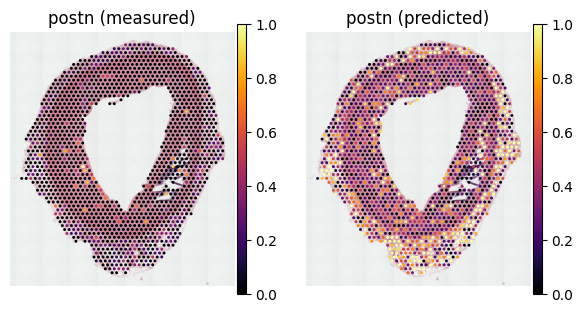

In [24]:
tg.plot_genes_sc(['postn'], adata_measured=ad_sp, adata_predicted=ad_ge, 
                 return_figure=False, perc = 0.1)